In [1]:
from pathlib import Path
path_to_data_notebook = Path.cwd().parent.parent / "Data" / "3_Preprocesed_data_v2.ipynb"
%run {path_to_data_notebook}

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import datetime 
import time
from sklearn.model_selection import train_test_split

# Data

In [3]:
size = 40
x_range_to_cut = 0.001
df = get_whole_preprocessed_dataframe()
# choosen property for y:
choosen_property_1 = "Total_surface_area[m2/g]"

df_with_data = df[df[choosen_property_1].notna()]    # get data if property are present
df_without_data = df[df[choosen_property_1].isna()]    # get data if property arent present

X = df_with_data['processed_flatten_isotherm_X_Y'] # x = 'processed_flatten_isotherm_X_Y'
y = df_with_data # y - temporary all columns for prediction inspection, in next steps we extract only choosen property

X_train, X_test, y_train_nested, y_test_nested, = train_test_split(X, y, test_size=0.02, random_state=42) #random_state=42

X_train = X_train.tolist()
X_test = X_test.tolist()
y_train = y_train_nested[choosen_property_1].to_numpy()
y_test = y_test_nested[choosen_property_1].to_numpy() 


scaler = StandardScaler() # only for x data
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test) 

print(f'X_train size = {len(X_train)}')
print(f'y_train size = {len(X_train)}')
print(f'X_test size = {len(X_test)}')
print(f'y_test size = {len(X_test)}')

X_without = df_without_data['processed_flatten_isotherm_X_Y'].tolist()
X_without = scaler.transform(X_without) 
y_without = df_without_data[choosen_property_1].to_numpy()
print(f'X_without size = {len(X_without)}')
print(f'y_without size = {len(y_without)}')

/home/pc/moje/python_projects/adsorbents_isotherms/Data/all_data.csv
------------------------------- Preprocessing_data start -------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Article_name                    1011 non-null   object 
 1   Figure_number                   1011 non-null   object 
 2   Sample_name                     1011 non-null   object 
 3   Total_surface_area[m2/g]        928 non-null    float64
 4   Total_pore_volume[cm3/g]        778 non-null    float64
 5   Micropore_volume[cm3/g]         730 non-null    float64
 6   Mesopore_volume[cm3/g]          21 non-null     float64
 7   Average_pore_diameter[nm]       121 non-null    float64
 8   Impregnation_ratio[agent/char]  20 non-null     float64
 9   Activation_type                 33 non-null     object 
 10

/home/pc/.cache/pypoetry/virtualenvs/adorbents-isotherms-FmcCsTt1-py3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/pc/.cache/pypoetry/virtualenvs/adorbents-isotherms-FmcCsTt1-py3.12/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<class 'pandas.core.frame.DataFrame'>
Index: 974 entries, 0 to 1010
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Article_name                    974 non-null    object 
 1   Figure_number                   974 non-null    object 
 2   Sample_name                     974 non-null    object 
 3   Total_surface_area[m2/g]        892 non-null    float64
 4   Total_pore_volume[cm3/g]        744 non-null    float64
 5   Micropore_volume[cm3/g]         714 non-null    float64
 6   Mesopore_volume[cm3/g]          21 non-null     float64
 7   Average_pore_diameter[nm]       121 non-null    float64
 8   Impregnation_ratio[agent/char]  20 non-null     float64
 9   Activation_type                 33 non-null     object 
 10  Burn_off[%]                     75 non-null     float64
 11  Carbonization_time[h]           210 non-null    float64
 12  Carbonization_temperature[stC]  253 non-

In [4]:
lista = []

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

def calculate_time(transcription_time):
    timedelta_obj = datetime.timedelta(seconds=int(transcription_time))
    return str(timedelta_obj)
size = 33
epochs_number = 500
model = tf.keras.Sequential([ 
    tf.keras.layers.Dense(size*4, activation='relu'), 
    tf.keras.layers.Dense(size*4, activation='relu'),
    # tf.keras.layers.Dense(size*3, activation='relu'),
    tf.keras.layers.Dense(1)                      
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
metrics=['mae', 'mse']
model.compile(optimizer=optimizer, loss='mse', metrics=metrics)
# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# history  =  model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=2)
start = time.time()
history  =  model.fit(X_train, y_train, epochs=epochs_number, batch_size=32, validation_split=0.1, verbose=2)
end = time.time()
transcription_time = calculate_time(round((end - start),2))
print(f"Model training time: "+transcription_time)
model.summary()
to_save = [model,"MLP"]
lista.append(to_save)

2025-03-22 23:02:28.564442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742680948.584672  133861 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742680948.590366  133861 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-22 23:02:28.609573: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Num GPUs Available:  1
Epoch 1/500


I0000 00:00:1742680950.077535  133861 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5
I0000 00:00:1742680951.045101  133920 service.cc:148] XLA service 0x716790003300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742680951.045134  133920 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2025-03-22 23:02:31.069229: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742680951.157103  133920 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1742680951.587324  133920 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 - 2s - 94ms/step - loss: 1575762.7500 - mae: 1057.9688 - mse: 1575762.7500 - val_loss: 1590025.5000 - val_mae: 1078.7042 - val_mse: 1590025.5000
Epoch 2/500
25/25 - 0s - 4ms/step - loss: 1516229.8750 - mae: 1033.7031 - mse: 1516229.8750 - val_loss: 1465925.8750 - val_mae: 1028.6128 - val_mse: 1465925.8750
Epoch 3/500
25/25 - 0s - 4ms/step - loss: 1326017.1250 - mae: 959.6350 - mse: 1326017.1250 - val_loss: 1156185.8750 - val_mae: 901.9883 - val_mse: 1156185.8750
Epoch 4/500
25/25 - 0s - 4ms/step - loss: 960679.7500 - mae: 827.2520 - mse: 960679.7500 - val_loss: 724549.8125 - val_mae: 736.3904 - val_mse: 724549.8125
Epoch 5/500
25/25 - 0s - 4ms/step - loss: 575140.8125 - mae: 663.5151 - mse: 575140.8125 - val_loss: 426805.9688 - val_mae: 573.4446 - val_mse: 426805.9688
Epoch 6/500
25/25 - 0s - 4ms/step - loss: 377885.5938 - mae: 524.9708 - mse: 377885.5938 - val_loss: 394987.2812 - val_mae: 505.3656 - val_mse: 394987.2812
Epoch 7/500
25/25 - 0s - 4ms/step - loss: 360428.7812 - mae

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 132)            │         4,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 132)            │        17,556 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           133 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,533 (259.90 KB)

 Trainable params: 22,177 (86.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,356 (173.27 KB)

Metrics: [6783.10302734375, 67.12811279296875, 6783.10302734375]
mae = 67.12811279296875
mse = 6783.10302734375


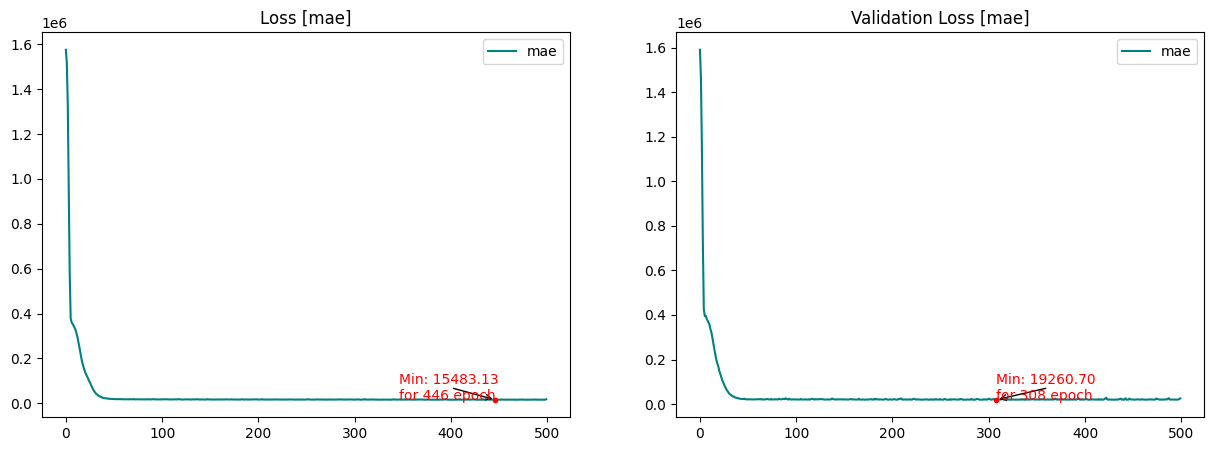

In [5]:

results = model.evaluate(X_test, y_test, verbose=0)
print("Metrics:",results)
for index, metric in enumerate(metrics):
    print(f"{metric} = {results[index+1]}")

from matplotlib import pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(15,5))

min_loss_idx = history.history['loss'].index(min(history.history['loss']))
min_loss = min(history.history['loss'])# Get the lowest  value
ax[0].plot(history.history['loss'], color='teal', label='mae')
# ax[0].plot(history.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss [mae]')
ax[0].legend()
ax[0].annotate(f'Min: {min_loss:.2f} \nfor {min_loss_idx} epoch', 
               xy=(min_loss_idx, min_loss), 
               xytext=(min_loss_idx - 100, min_loss + 100),  # Adjust text position
               arrowprops=dict(facecolor='red', arrowstyle="->"),
               color='red')
ax[0].plot(min_loss_idx, min_loss, 'ro',markersize=3)# Plot a dot at the minimum point


min_val_loss_idx = history.history['val_loss'].index(min(history.history['val_loss']))# Find the index of the minimum 
min_val_loss = min(history.history['val_loss'])# Get the lowest  value
ax[1].plot(history.history['val_loss'], color='teal', label='mae')
# ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Validation Loss [mae]')
ax[1].legend() 
# Annotate the lowest point on the validation loss curve
ax[1].annotate(f'Min: {min_val_loss:.2f} \nfor {min_val_loss_idx} epoch', 
               xy=(min_val_loss_idx, min_val_loss), 
               xytext=(min_val_loss_idx, min_val_loss),  # Adjust text position
               arrowprops=dict(facecolor='red', arrowstyle="->"),
               color='red')
ax[1].plot(min_val_loss_idx, min_val_loss, 'ro', markersize=3)# Plot a dot at the minimum point

# ax[2].plot(history.history['val_mse'], color='teal', label='regress loss')
# # ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
# ax[2].title.set_text('Validation mse')
# ax[2].legend()

plt.show()

# fig.savefig('zwykle.jpg', dpi=100)

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
to_save = [model,"LinearRegression"]
lista.append(to_save)

from sklearn.linear_model import SGDRegressor
model = SGDRegressor(max_iter=10000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
model.fit(X_train, y_train.ravel())  # y.ravel() because fit() expects 1D targets
to_save = [model,"SGDRegressor"]
lista.append(to_save)

from sklearn.linear_model import Ridge
model = Ridge(alpha=0.1, solver="cholesky")
model.fit(X_train, y_train)
to_save = [model,"Ridge"]
lista.append(to_save)

from sklearn.linear_model import Lasso
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
to_save = [model,"Lasso"]
lista.append(to_save)

from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
to_save = [model,"ElasticNet"]
lista.append(to_save)

from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=2, random_state=42)
model.fit(X_train, y_train)
to_save = [model,"TreeRegressor"]
lista.append(to_save)

from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor( n_neighbors=2 )
model.fit(X_train, y_train)
to_save = [model,"KNeighbors"]
lista.append(to_save)

from sklearn.svm import LinearSVR
model = LinearSVR(epsilon=0.5, dual=True, random_state=42)
model.fit(X_train, y_train)
to_save = [model,"LinearSVR"]
lista.append(to_save)

from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0, random_state=42)
model.fit(X_train, y_train)
to_save = [model,"GBRegressor"]
lista.append(to_save)

from sklearn.ensemble import HistGradientBoostingRegressor
model =  HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
model.fit(X_train, y_train)
to_save = [model,"HistGBRegressor"]
lista.append(to_save)


/home/pc/.cache/pypoetry/virtualenvs/adorbents-isotherms-FmcCsTt1-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.345e+06, tolerance: 3.977e+04
  model = cd_fast.enet_coordinate_descent(
/home/pc/.cache/pypoetry/virtualenvs/adorbents-isotherms-FmcCsTt1-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.102e+06, tolerance: 3.977e+04
  model = cd_fast.enet_coordinate_descent(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Max error: [165.36865234] dla MLP        Data151 5 PAC8  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 184.46575488489566 dla LinearRegression        Data132 3 C-600  for error treshold[30] - 33.33%     6 izotermy na 18 
Max error: 147.17259127174702 dla SGDRegressor        Data151 5 PAC8  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 175.8899279165007 dla Ridge        Data132 3 C-600  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 144.74384827606127 dla Lasso        Data132 3 C-600  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 151.68757248148336 dla ElasticNet        Data132 3 C-600  for error treshold[30] - 33.33%     6 izotermy na 18 
Max error: 509.22768156424604 dla TreeRegressor        Data132 3 C-600  for error treshold[30] - 11.11%     2 izotermy na 18 
Max error: 281.5 dla KNeighbors        Data132 3 C-600  for error treshold[30] - 33.33%     6 izotermy na 18 
Max

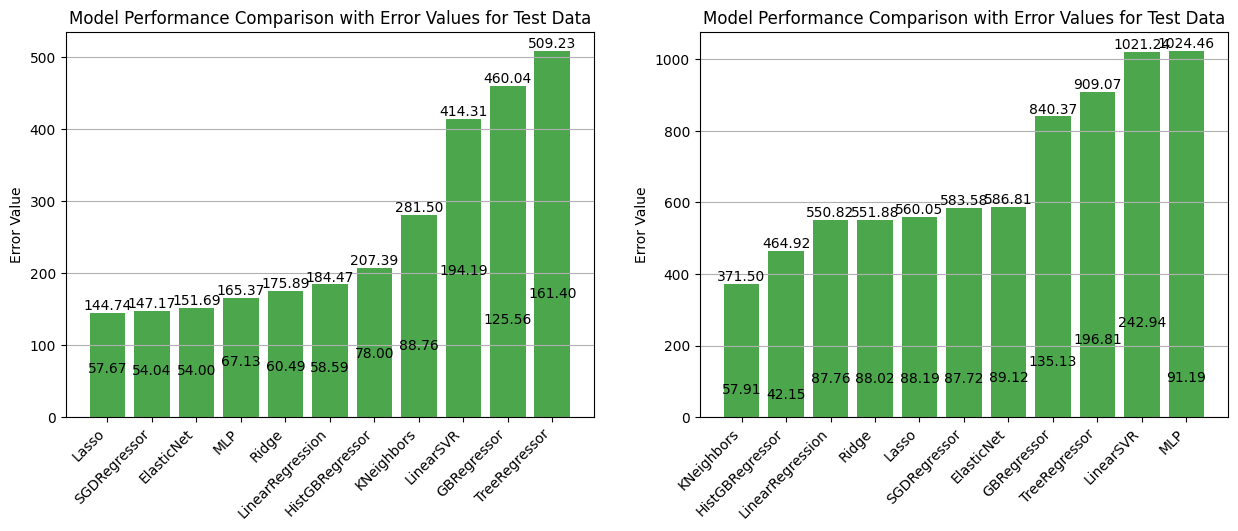

In [7]:
max_errors_from_models = []
list_for_plot = []
for model, name in lista:
    predictions_test = model.predict(X_test)
    y_test_for_compare = y_test
    y_dataframe = y_test_nested
    error_threshold = 30
    max_error_threshold = 30
    list_below =[]
    list_above=[]
    errors = []
    for i in range(len(predictions_test)):
        data_name = y_dataframe.iloc[i,0]
        graph_number = y_dataframe.iloc[i,1]
        sample_name = y_dataframe.iloc[i,2]
        error = abs(predictions_test[i] - y_test_for_compare[i])
        errors.append(error)
        if(error_threshold<=error):
            list_above.append(i)
        else: list_below.append(i)
    max_error_index = errors.index(max(errors))
    max_error_data_name = y_dataframe.iloc[max_error_index,0]
    max_error_graph_number = y_dataframe.iloc[max_error_index,1]
    max_error_sample_name = y_dataframe.iloc[max_error_index,2]
    text_to_display = f"Max error: {max(errors)} dla {name}        {max_error_data_name} {max_error_graph_number} {max_error_sample_name}  "   + f"for error treshold[{error_threshold}] - {round((len(list_below)/len(predictions_test))*100,2)}%     {len(list_below)} izotermy na {len(predictions_test)} " 
    print(text_to_display)
    max_errors_from_models.append(max(errors))
    mean = np.mean(errors)
    list_for_plot.append([max(errors),name, mean])
model_with_max_error_index = max_errors_from_models.index(max(max_errors_from_models))
model_with_min_error_index = max_errors_from_models.index(min(max_errors_from_models))
print(f'errors.index(max(errors)) = {max_errors_from_models[model_with_max_error_index]} for {lista[model_with_max_error_index][1]}')
print(f'errors.index(min(errors)) = {max_errors_from_models[model_with_min_error_index]} for {lista[model_with_min_error_index][1]}')

import matplotlib.pyplot as plt
import numpy as np
list_for_plot = sorted(list_for_plot, key=lambda x: x[0])
models =  [item[1] for item in list_for_plot]
errors = [float(item[0].item()) if isinstance(item[0], np.ndarray) else float(item[0]) for item in list_for_plot]
MEANS = [float(item[2]) for item in list_for_plot]

y_pos = np.arange(len(list_for_plot))

fig, ax = plt.subplots(ncols=2, figsize=(15,5))
ax[0].bar(y_pos, errors,  alpha=0.7, color='g', capsize=5)
ax[0].set_xticks(y_pos, models, rotation=45, ha='right')
ax[0].set_ylabel('Error Value')
ax[0].set_title('Model Performance Comparison with Error Values for Test Data')
for i, error in enumerate(errors):
    ax[0].text(y_pos[i], error , f'{error:.2f}', ha='center', va='bottom')
for i, error in enumerate(MEANS):
    ax[0].text(y_pos[i], error , f'{error:.2f}', ha='center', va='bottom',color='black')
ax[0].grid(axis='y')

# --------------------- train data --------------------------

max_errors_from_models = []
list_for_plot = []
for model, name in lista:
    predictions_test = model.predict(X_train)
    y_test_for_compare = y_train
    y_dataframe = y_train_nested
    error_threshold = 30
    max_error_threshold = 30
    list_below =[]
    list_above=[]
    errors = []
    for i in range(len(predictions_test)):
        data_name = y_dataframe.iloc[i,0]
        graph_number = y_dataframe.iloc[i,1]
        sample_name = y_dataframe.iloc[i,2]
        error = abs(predictions_test[i] - y_test_for_compare[i])
        errors.append(error)
        if(error_threshold<=error):
            list_above.append(i)
        else: list_below.append(i)
    max_error_index = errors.index(max(errors))
    max_error_data_name = y_dataframe.iloc[max_error_index,0]
    max_error_graph_number = y_dataframe.iloc[max_error_index,1]
    max_error_sample_name = y_dataframe.iloc[max_error_index,2]
    text_to_display = f"Max error: {max(errors)} dla {name}        {max_error_data_name} {max_error_graph_number} {max_error_sample_name}  "   + f"for error treshold[{error_threshold}] - {round((len(list_below)/len(predictions_test))*100,2)}%     {len(list_below)} izotermy na {len(predictions_test)} " 
    print(text_to_display)
    max_errors_from_models.append(max(errors))
    mean = np.mean(errors)
    list_for_plot.append([max(errors),name, mean])
model_with_max_error_index = max_errors_from_models.index(max(max_errors_from_models))
model_with_min_error_index = max_errors_from_models.index(min(max_errors_from_models))
print(f'errors.index(max(errors)) = {max_errors_from_models[model_with_max_error_index]} for {lista[model_with_max_error_index][1]}')
print(f'errors.index(min(errors)) = {max_errors_from_models[model_with_min_error_index]} for {lista[model_with_min_error_index][1]}')

list_for_plot = sorted(list_for_plot, key=lambda x: x[0])
models =  [item[1] for item in list_for_plot]
errors = [float(item[0].item()) if isinstance(item[0], np.ndarray) else float(item[0]) for item in list_for_plot]
MEANS = [float(item[2]) for item in list_for_plot]
y_pos = np.arange(len(list_for_plot))
ax[1].bar(y_pos, errors,  alpha=0.7, color='g', capsize=5)
ax[1].set_xticks(y_pos, models, rotation=45, ha='right')
ax[1].set_ylabel('Error Value')
ax[1].set_title('Model Performance Comparison with Error Values for Train Data')
for i, error in enumerate(errors):
    ax[1].text(y_pos[i], error , f'{error:.2f}', ha='center', va='bottom')
for i, error in enumerate(MEANS):
    ax[1].text(y_pos[i], error , f'{error:.2f}', ha='center', va='bottom',color='black')
ax[1].grid(axis='y')
# ax[0].set_tight_layout()
plt.show()


# Test data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Max error: [165.36865234] dla MLP        Data151 5 PAC8  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 184.46575488489566 dla LinearRegression        Data132 3 C-600  for error treshold[30] - 33.33%     6 izotermy na 18 
Max error: 147.17259127174702 dla SGDRegressor        Data151 5 PAC8  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 175.8899279165007 dla Ridge        Data132 3 C-600  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 144.74384827606127 dla Lasso        Data132 3 C-600  for error treshold[30] - 27.78%     5 izotermy na 18 
Max error: 151.68757248148336 dla ElasticNet        Data132 3 C-600  for error treshold[30] - 33.33%     6 izotermy na 18 
Max error: 509.22768156424604 dla TreeRegressor        Data132 3 C-600  for error treshold[30] - 11.11%     2 izotermy na 18 
Max error: 281.5 dla KNeighbors        Data132 3 C-600  for error treshold[30] - 33.33%     6 izotermy na 18 
Max 

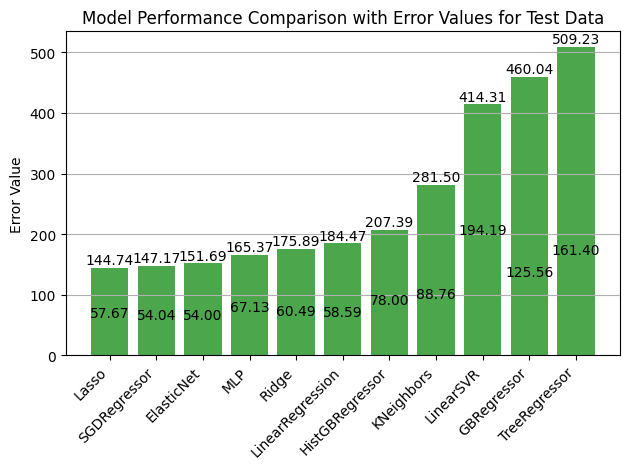

In [8]:
max_errors_from_models = []
list_for_plot = []
for model, name in lista:
    predictions_test = model.predict(X_test)
    y_test_for_compare = y_test
    y_dataframe = y_test_nested
    error_threshold = 30
    max_error_threshold = 30
    list_below =[]
    list_above=[]
    errors = []
    for i in range(len(predictions_test)):
        data_name = y_dataframe.iloc[i,0]
        graph_number = y_dataframe.iloc[i,1]
        sample_name = y_dataframe.iloc[i,2]
        error = abs(predictions_test[i] - y_test_for_compare[i])
        errors.append(error)
        if(error_threshold<=error):
            list_above.append(i)
        else: list_below.append(i)
    max_error_index = errors.index(max(errors))
    max_error_data_name = y_dataframe.iloc[max_error_index,0]
    max_error_graph_number = y_dataframe.iloc[max_error_index,1]
    max_error_sample_name = y_dataframe.iloc[max_error_index,2]
    text_to_display = f"Max error: {max(errors)} dla {name}        {max_error_data_name} {max_error_graph_number} {max_error_sample_name}  "   + f"for error treshold[{error_threshold}] - {round((len(list_below)/len(predictions_test))*100,2)}%     {len(list_below)} izotermy na {len(predictions_test)} " 
    print(text_to_display)
    max_errors_from_models.append(max(errors))
    mean = np.mean(errors)
    list_for_plot.append([max(errors),name, mean])
model_with_max_error_index = max_errors_from_models.index(max(max_errors_from_models))
model_with_min_error_index = max_errors_from_models.index(min(max_errors_from_models))
print(f'errors.index(max(errors)) = {max_errors_from_models[model_with_max_error_index]} for {lista[model_with_max_error_index][1]}')
print(f'errors.index(min(errors)) = {max_errors_from_models[model_with_min_error_index]} for {lista[model_with_min_error_index][1]}')

import matplotlib.pyplot as plt
import numpy as np
list_for_plot = sorted(list_for_plot, key=lambda x: x[0])
models =  [item[1] for item in list_for_plot]
errors = [float(item[0].item()) if isinstance(item[0], np.ndarray) else float(item[0]) for item in list_for_plot]
MEANS = [float(item[2]) for item in list_for_plot]
plt.figure()
y_pos = np.arange(len(list_for_plot))
plt.bar(y_pos, errors,  alpha=0.7, color='g', capsize=5)
plt.xticks(y_pos, models, rotation=45, ha='right')
plt.ylabel('Error Value')
plt.title('Model Performance Comparison with Error Values for Test Data')
for i, error in enumerate(errors):
    plt.text(y_pos[i], error + 1, f'{error:.2f}', ha='center', va='bottom')
for i, error in enumerate(MEANS):
    plt.text(y_pos[i], error + 1, f'{error:.2f}', ha='center', va='bottom',color='black')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Train data

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Max error: [1024.45727539] dla MLP        Data88 1 CAC  for error treshold[30] - 29.75%     260 izotermy na 874 
Max error: 550.8235564897807 dla LinearRegression        Data9 4 GC-C02  for error treshold[30] - 25.63%     224 izotermy na 874 
Max error: 583.577126134732 dla SGDRegressor        Data9 4 GC-C02  for error treshold[30] - 28.6%     250 izotermy na 874 
Max error: 551.8761528980126 dla Ridge        Data9 4 GC-C02  for error treshold[30] - 26.2%     229 izotermy na 874 
Max error: 560.0539387425806 dla Lasso        Data9 4 GC-C02  for error treshold[30] - 25.97%     227 izotermy na 874 
Max error: 586.8098135882067 dla ElasticNet        Data47 1 ACF45M  for error treshold[30] - 29.29%     256 izotermy na 874 
Max error: 909.0745901639343 dla TreeRegressor        Data155 1 VR5-4-1  for error treshold[30] - 7.09%     62 izotermy na 874 
Max error: 371.5 dla KNeighbors        Data156 1 K3  for error treshold[30] - 47.71%     417 izotermy n

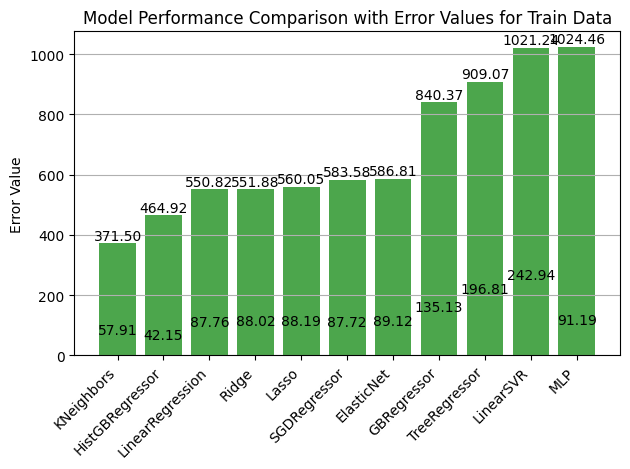

In [9]:
max_errors_from_models = []
list_for_plot = []
for model, name in lista:
    predictions_test = model.predict(X_train)
    y_test_for_compare = y_train
    y_dataframe = y_train_nested
    error_threshold = 30
    max_error_threshold = 30
    list_below =[]
    list_above=[]
    errors = []
    for i in range(len(predictions_test)):
        data_name = y_dataframe.iloc[i,0]
        graph_number = y_dataframe.iloc[i,1]
        sample_name = y_dataframe.iloc[i,2]
        error = abs(predictions_test[i] - y_test_for_compare[i])
        errors.append(error)
        if(error_threshold<=error):
            list_above.append(i)
        else: list_below.append(i)
    max_error_index = errors.index(max(errors))
    max_error_data_name = y_dataframe.iloc[max_error_index,0]
    max_error_graph_number = y_dataframe.iloc[max_error_index,1]
    max_error_sample_name = y_dataframe.iloc[max_error_index,2]
    text_to_display = f"Max error: {max(errors)} dla {name}        {max_error_data_name} {max_error_graph_number} {max_error_sample_name}  "   + f"for error treshold[{error_threshold}] - {round((len(list_below)/len(predictions_test))*100,2)}%     {len(list_below)} izotermy na {len(predictions_test)} " 
    print(text_to_display)
    max_errors_from_models.append(max(errors))
    mean = np.mean(errors)
    list_for_plot.append([max(errors),name, mean])
model_with_max_error_index = max_errors_from_models.index(max(max_errors_from_models))
model_with_min_error_index = max_errors_from_models.index(min(max_errors_from_models))
print(f'errors.index(max(errors)) = {max_errors_from_models[model_with_max_error_index]} for {lista[model_with_max_error_index][1]}')
print(f'errors.index(min(errors)) = {max_errors_from_models[model_with_min_error_index]} for {lista[model_with_min_error_index][1]}')

import matplotlib.pyplot as plt
import numpy as np
list_for_plot = sorted(list_for_plot, key=lambda x: x[0])
models =  [item[1] for item in list_for_plot]
errors = [float(item[0].item()) if isinstance(item[0], np.ndarray) else float(item[0]) for item in list_for_plot]
MEANS = [float(item[2]) for item in list_for_plot]
plt.figure()
y_pos = np.arange(len(list_for_plot))
plt.bar(y_pos, errors,  alpha=0.7, color='g', capsize=5)
plt.xticks(y_pos, models, rotation=45, ha='right')
plt.ylabel('Error Value')
plt.title('Model Performance Comparison with Error Values for Train Data')
for i, error in enumerate(errors):
    plt.text(y_pos[i], error + 1, f'{error:.2f}', ha='center', va='bottom')
for i, error in enumerate(MEANS):
    plt.text(y_pos[i], error + 1, f'{error:.2f}', ha='center', va='bottom',color='black')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [10]:
predictions_for_data_without = model.predict(X_without)
for i in range(len(predictions_for_data_without)):
    print(f'{predictions_for_data_without[i]:.2f}    <---->  {y_without[i]:.2f}   ')

497.96    <---->  nan   
106.12    <---->  nan   
106.12    <---->  nan   
106.12    <---->  nan   
116.34    <---->  nan   
106.12    <---->  nan   
148.77    <---->  nan   
160.57    <---->  nan   
983.62    <---->  nan   
1240.79    <---->  nan   
2071.85    <---->  nan   
734.02    <---->  nan   
1226.90    <---->  nan   
1690.73    <---->  nan   
1180.15    <---->  nan   
1871.84    <---->  nan   
1561.99    <---->  nan   
826.48    <---->  nan   
1143.74    <---->  nan   
419.03    <---->  nan   
1098.57    <---->  nan   
2298.49    <---->  nan   
365.02    <---->  nan   
628.66    <---->  nan   
934.79    <---->  nan   
775.90    <---->  nan   
838.86    <---->  nan   
623.45    <---->  nan   
1102.87    <---->  nan   
1056.68    <---->  nan   
2472.61    <---->  nan   
2496.19    <---->  nan   
2506.92    <---->  nan   
1759.13    <---->  nan   
808.84    <---->  nan   
1103.81    <---->  nan   
1900.73    <---->  nan   
2090.81    <---->  nan   
589.53    <---->  nan   
627.76